# Real Data Analysis (no synthetic data)

This notebook processes only the real recordings collected so far:

1. `data/raw/background_noise.xls` — a real Audio Amplitude background
   recording (quiet room, no ball drops).
2. `data/raw/scope_noisy_one_bounce_test.xls` — a real Audio Scope test
   capture (one bounce, in a noisy environment).
3. `data/raw/scope_0.3m_test.xls` — a real Audio Scope test, single drop
   from a known height (0.3 m).
4-13. `data/raw/amp_{0.3,0.4,...,1.2}m_5bounce_test.xls` — real Audio
   Amplitude recordings of ~5 repeated drops each, at ten heights spanning
   0.3-1.2 m in 0.1 m steps.

Files 4-13 give the first real multi-height g result in this project
(Sections D-G) — ten heights, meeting the protocol's >= 8-height target,
enough to properly check compatibility across heights and see where the
method's assumptions start to strain.

For the full pipeline logic and its validation against synthetic data with
known ground truth, see `notebooks/analysis.ipynb`.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import io_utils
import cleaning
import noise_characterization as noise
import bounce_detection as bd
import segmentation
import fitting
from pipeline import process_multi_drop_recording

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11


## A. Background noise (Audio Amplitude)

Real 10-minute quiet-room recording. The first/last 10 s are trimmed
(handling noise from starting/stopping the phyphox recording), then the
noise floor and a bounce-detection threshold are computed.


Loaded 4991 samples, 615.7 s.


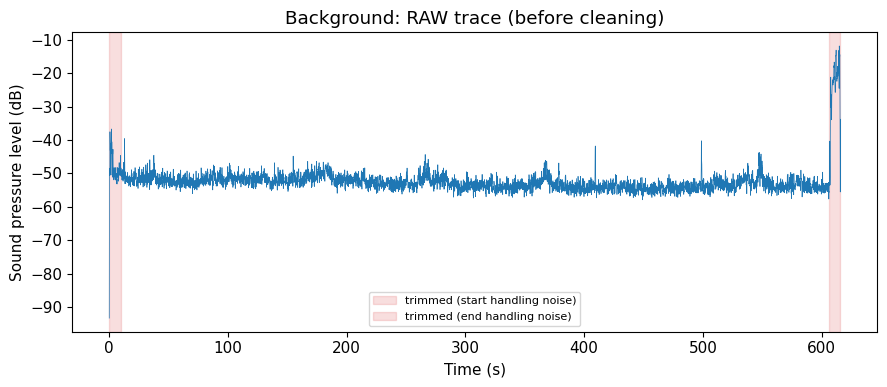

In [2]:
bg_raw = io_utils.load_audio_amplitude("../data/raw/background_noise.xls")
print(f"Loaded {len(bg_raw)} samples, {bg_raw['time_s'].max():.1f} s.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bg_raw["time_s"], bg_raw["spl_db"], lw=0.5)
ax.axvspan(0, 10, color="C3", alpha=0.15, label="trimmed (start handling noise)")
ax.axvspan(bg_raw["time_s"].max() - 10, bg_raw["time_s"].max(), color="C3", alpha=0.15,
           label="trimmed (end handling noise)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Sound pressure level (dB)")
ax.set_title("Background: RAW trace (before cleaning)")
ax.legend(fontsize=8)
plt.tight_layout()
# Not saved as a separate file: identical analysis to notebooks/analysis.ipynb
# Section 1 (same background_noise.xls) -- see figures/background_before_cleaning.png.
plt.show()


In [3]:
bg, clean_report = cleaning.trim_and_clean(bg_raw, trim_start_s=10.0, trim_end_s=10.0)
print(cleaning.cleaning_summary_text(clean_report))

profile = noise.characterise(bg, k_sigma=5.0)
print()
print(noise.summary_text(profile))


Trimmed first 10 s and last 10 s (handling noise); dropped 0 NaN samples.
Retained 4827 / 4991 samples (96.7%).

Samples: 4827 (NaN at start: 0)
Noise floor: mean = -52.79 dB, std = 1.98 dB, median = -52.92 dB, 95th pct = -49.40 dB, max transient = -39.54 dB
Sampling interval: mean = 123.4 ms, median = 122.9 ms, std = 6.1 ms, range = [102.3, 152.4] ms
Recommended bounce-detection threshold: -42.88 dB (mean + k*std)


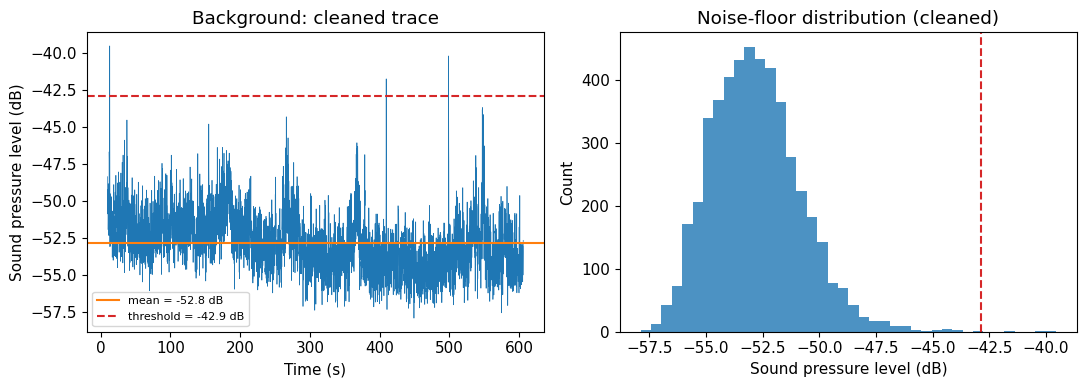

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(bg["time_s"], bg["spl_db"], lw=0.5)
axes[0].axhline(profile.mean_db, color="C1", label=f"mean = {profile.mean_db:.1f} dB")
axes[0].axhline(profile.recommended_threshold_db, color="C3", ls="--",
                label=f"threshold = {profile.recommended_threshold_db:.1f} dB")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Sound pressure level (dB)")
axes[0].set_title("Background: cleaned trace")
axes[0].legend(fontsize=8)

axes[1].hist(bg["spl_db"].dropna(), bins=40, color="C0", alpha=0.8)
axes[1].axvline(profile.recommended_threshold_db, color="C3", ls="--")
axes[1].set_xlabel("Sound pressure level (dB)")
axes[1].set_ylabel("Count")
axes[1].set_title("Noise-floor distribution (cleaned)")

plt.tight_layout()
# Not saved as a separate file: see figures/noise_floor.png (same source data/analysis).
plt.show()


### Temporal resolution this recording mode allows

Given the real sampling interval measured above, here is how many
inter-bounce intervals would be resolvable at representative heights (see
`notebooks/analysis.ipynb` Section 1 for the full derivation) -- this uses
only the real measured sampling statistics, not synthetic data:


In [5]:
for h0_demo, e_demo in [(0.5, 0.75), (1.0, 0.8), (1.5, 0.85)]:
    A_demo = 2 * np.sqrt(2 * h0_demo / 9.783)
    n_max = noise.resolvable_bounce_count(profile, A_demo, e_demo, nyquist_factor=2.0)
    print(f"h0={h0_demo} m, e={e_demo}: A={A_demo:.3f} s, "
          f"usable bounces before aliasing risk: n <= {n_max}")


h0=0.5 m, e=0.75: A=0.639 s, usable bounces before aliasing risk: n <= 3
h0=1.0 m, e=0.8: A=0.904 s, usable bounces before aliasing risk: n <= 5
h0=1.5 m, e=0.85: A=1.108 s, usable bounces before aliasing risk: n <= 9


## B. Real Audio Scope test ("noisy one bounce")

Raw waveform and its processed envelope, for the one real Audio Scope
capture collected so far.


Loaded 24000 raw samples spanning 500.0 ms (confirms phyphox's Audio Scope export is a short rolling buffer, not the full recording session).


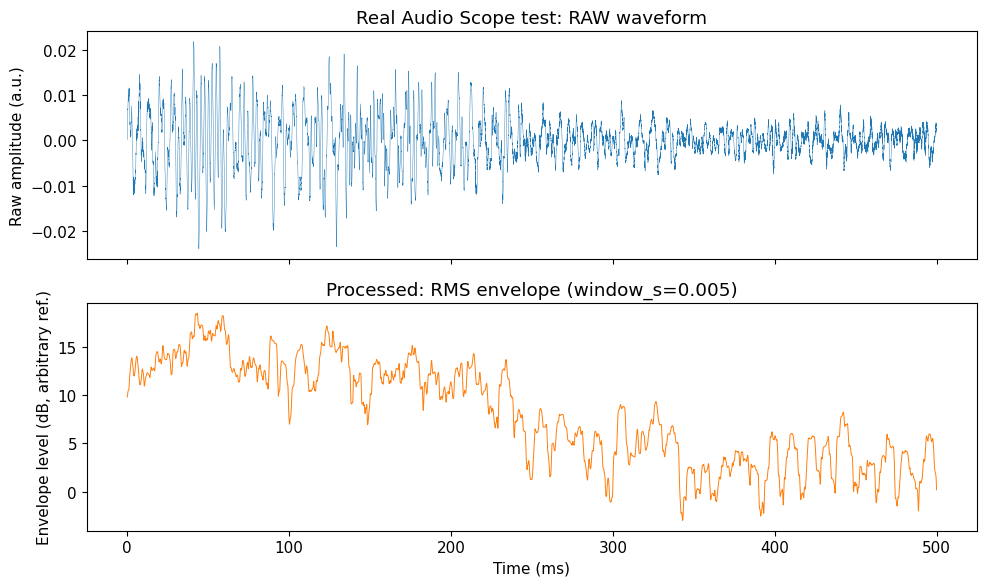

In [6]:
real_scope_path = "../data/raw/scope_noisy_one_bounce_test.xls"
real_scope_raw = io_utils.load_scope_raw(real_scope_path)
real_scope_env = io_utils.load_recording(real_scope_path, window_s=0.005)

print(f"Loaded {len(real_scope_raw)} raw samples spanning "
      f"{real_scope_raw['time_s'].max()*1000:.1f} ms "
      f"(confirms phyphox's Audio Scope export is a short rolling buffer, "
      f"not the full recording session).")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(real_scope_raw["time_s"] * 1000, real_scope_raw["amplitude"], lw=0.3)
axes[0].set_ylabel("Raw amplitude (a.u.)")
axes[0].set_title("Real Audio Scope test: RAW waveform")

axes[1].plot(real_scope_env["time_s"] * 1000, real_scope_env["spl_db"], lw=0.7, color="C1")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Envelope level (dB, arbitrary ref.)")
axes[1].set_title("Processed: RMS envelope (window_s=0.005)")

plt.tight_layout()
plt.savefig("../figures/real_scope_raw_and_processed.png", dpi=150)
plt.show()


### Noise floor and detection

This file's own noise floor is characterised from the quiet region only
(excluding a window around the loudest point), since no dedicated quiet
Audio Scope background has been recorded yet. `k_sigma=5` (the default used
for the Audio Amplitude background above, which is a genuinely quiet
recording) finds **nothing** here -- the signal is only marginally above
the noise in this "noisy" test, so `k_sigma` is lowered and that trade-off
(more sensitive, higher false-positive risk) is reported explicitly rather
than hidden.


In [7]:
peak_idx = real_scope_env["spl_db"].idxmax()
peak_t = real_scope_env["time_s"].iloc[peak_idx]

real_profile_strict = noise.characterise_excluding_window(
    real_scope_env, exclude_center_s=peak_t, exclude_width_s=0.05, k_sigma=5.0, robust=True)
real_profile = noise.characterise_excluding_window(
    real_scope_env, exclude_center_s=peak_t, exclude_width_s=0.05, k_sigma=1.5, robust=True)

print("k_sigma=5.0 (default):", noise.summary_text(real_profile_strict))
times_strict = bd.detect_bounces_peak_picking(real_scope_env, real_profile_strict.recommended_threshold_db,
                                               min_separation_s=0.02, prominence_db=2.0)
print(f"  -> {len(times_strict)} candidate impact(s) detected: "
      f"{[round(x*1000,1) for x in times_strict]} ms")

print()
print("k_sigma=1.5 (lowered -- needed to detect anything in this noisy test):")
print(noise.summary_text(real_profile))
times = bd.detect_bounces_peak_picking(real_scope_env, real_profile.recommended_threshold_db,
                                        min_separation_s=0.02, prominence_db=2.0)
print(f"  -> {len(times)} candidate impact(s) detected: {[round(x*1000,1) for x in times]} ms")

snr_sigma = (real_scope_env["spl_db"].max() - real_profile.mean_db) / real_profile.std_db
print(f"\nPeak is only {snr_sigma:.1f} sigma above the quiet-region estimate -- a weak margin.")


k_sigma=5.0 (default): Samples: 21601 (NaN at start: 0)
Noise floor: mean = 6.58 dB, std = 6.34 dB, median = 6.58 dB, 95th pct = 14.64 dB, max transient = 17.13 dB
Sampling interval: mean = 0.0 ms, median = 0.0 ms, std = 0.3 ms, range = [0.0, 50.0] ms
Recommended bounce-detection threshold: 38.28 dB (mean + k*std)
  -> 0 candidate impact(s) detected: [] ms

k_sigma=1.5 (lowered -- needed to detect anything in this noisy test):
Samples: 21601 (NaN at start: 0)
Noise floor: mean = 6.58 dB, std = 6.34 dB, median = 6.58 dB, 95th pct = 14.64 dB, max transient = 17.13 dB
Sampling interval: mean = 0.0 ms, median = 0.0 ms, std = 0.3 ms, range = [0.0, 50.0] ms
Recommended bounce-detection threshold: 16.09 dB (mean + k*std)
  -> 2 candidate impact(s) detected: [43.2, 123.3] ms

Peak is only 1.9 sigma above the quiet-region estimate -- a weak margin.


### What this test does and does not tell us

**What it confirms:**
- The ingestion code correctly parses a real multi-sheet Audio Scope `.xls`
  export (`Time (ms)`, `Recording (a.u.)`).
- A real Audio Scope capture is limited to ~0.5 s regardless of session
  length.
- In a genuinely noisy environment, the bounce signal can sit within only
  ~2σ of the room-noise floor, which is a real, reportable constraint on
  this method's reliability -- not just a validation artefact.

**What it cannot give us (and why):**
- **No Δt.** Computing an inter-bounce interval needs >= 2 *confirmed*
  impacts. At `k_sigma=1.5` two candidates appear, but at this SNR a second
  detection cannot be confidently distinguished from ordinary room noise
  (see the raw waveform above -- the noisy region has many comparable
  bumps, not one isolated clean spike).
- **No g.** Even with a confirmed Δt, `g = 8 h0 / A^2` needs the drop
  height h0, which was not logged for this test (it was a detection
  feasibility check, not a measurement trial).

### What's needed for a real g measurement

Per `report/data_collection_protocol.md`: >= 8 real drop heights (0.3-1.5 m)
recorded with logged heights and uncertainties, in a quieter environment
than this test, using either Workflow A (one Audio Amplitude file per
height) or Workflow B (one continuous multi-drop recording). Once those
files exist in `data/raw/`, they slot directly into
`notebooks/analysis.ipynb` Section 6's real-data template.


## C. Real Audio Scope test, 0.3 m drop (known height)

Unlike Section B, this capture has a **known drop height (0.3 m)** and,
visually, a single clean, sharp, isolated spike rather than sustained noisy
activity -- a much better test case.


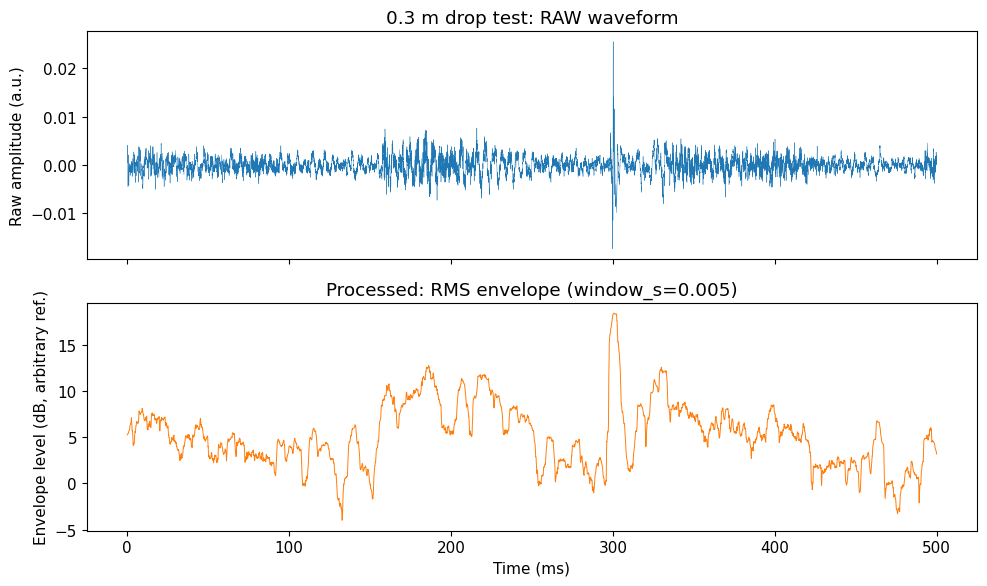

In [8]:
h03_path = "../data/raw/scope_0.3m_test.xls"
h03_raw = io_utils.load_scope_raw(h03_path)
h03_env = io_utils.load_recording(h03_path, window_s=0.005)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(h03_raw["time_s"] * 1000, h03_raw["amplitude"], lw=0.3)
axes[0].set_ylabel("Raw amplitude (a.u.)")
axes[0].set_title("0.3 m drop test: RAW waveform")

axes[1].plot(h03_env["time_s"] * 1000, h03_env["spl_db"], lw=0.7, color="C1")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Envelope level (dB, arbitrary ref.)")
axes[1].set_title("Processed: RMS envelope (window_s=0.005)")

plt.tight_layout()
plt.savefig("../figures/real_scope_0.3m_raw_and_processed.png", dpi=150)
plt.show()


In [9]:
peak_idx = h03_env["spl_db"].idxmax()
peak_t = h03_env["time_s"].iloc[peak_idx]

for ks in [5.0, 3.0, 2.0, 1.5]:
    prof = noise.characterise_excluding_window(h03_env, exclude_center_s=peak_t,
                                                exclude_width_s=0.05, k_sigma=ks, robust=True)
    times = bd.detect_bounces_peak_picking(h03_env, prof.recommended_threshold_db,
                                            min_separation_s=0.02, prominence_db=2.0)
    print(f"k_sigma={ks}: threshold={prof.recommended_threshold_db:5.2f} dB "
          f"-> {len(times)} detection(s): {[round(x*1000,1) for x in times]} ms")


k_sigma=5.0: threshold=21.26 dB -> 0 detection(s): [] ms
k_sigma=3.0: threshold=14.74 dB -> 1 detection(s): [300.8] ms
k_sigma=2.0: threshold=11.48 dB -> 4 detection(s): [186.2, 220.7, 300.8, 329.9] ms
k_sigma=1.5: threshold= 9.85 dB -> 5 detection(s): [161.6, 186.2, 220.7, 300.8, 329.9] ms


`k_sigma=3.0` is the tightest setting that still detects the visible spike,
and it detects **exactly one** impact -- the others seen at lower `k_sigma`
are the same kind of room-noise bumps visible elsewhere in the trace, not
physically plausible second bounces (a real second bounce at this height
would be expected around `A*e ~ 0.37-0.42 s` after the first impact, i.e.
close to or beyond the edge of this 0.5 s buffer -- not the ~30-140 ms gaps
these extra low-threshold detections show).


In [10]:
threshold_ks3 = noise.characterise_excluding_window(
    h03_env, exclude_center_s=peak_t, exclude_width_s=0.05, k_sigma=3.0, robust=True
).recommended_threshold_db
impact_times = bd.detect_bounces_peak_picking(h03_env, threshold_ks3, min_separation_s=0.02, prominence_db=2.0)
t_impact = impact_times[0]
print(f"Single confirmed impact at t = {t_impact*1000:.2f} ms")


Single confirmed impact at t = 300.78 ms


### An honest single-point g estimate

With only **one** confirmed acoustic event, the bounce-restitution model
(which needs >= 2 impacts to form a Δt) cannot be used. But the height is
known here, so the direct free-fall relation (the same one Method 4,
Free Fall Acoustic, is built on) can be applied instead:

$$t^2 = \frac{2h_0}{g} \implies g = \frac{2h_0}{t^2}$$

**This requires assuming the recording started at the moment of release**
-- phyphox's Audio Scope has no separate "release" trigger, so t here is
measured from the start of the buffer, not from a confirmed release event.
That assumption is the dominant, unquantified systematic in the number
below; it is not a statistical uncertainty and no error bar is reported,
because a single point gives none.


In [11]:
h0_known = 0.30
g_ref = 9.783

g_single = 2 * h0_known / t_impact**2
t_theoretical = np.sqrt(2 * h0_known / g_ref)
implied_offset_ms = (t_impact - t_theoretical) * 1000

print(f"Assumed h0 = {h0_known} m, measured t (buffer start -> impact) = {t_impact*1000:.2f} ms")
print(f"g (single-point, free-fall) = {g_single:.2f} m/s^2")
print(f"For comparison, g_ref = {g_ref} m/s^2 implies a theoretical fall time of "
      f"{t_theoretical*1000:.2f} ms")
print(f"Difference (observed - theoretical): {implied_offset_ms:.1f} ms")


Assumed h0 = 0.3 m, measured t (buffer start -> impact) = 300.78 ms
g (single-point, free-fall) = 6.63 m/s^2
For comparison, g_ref = 9.783 m/s^2 implies a theoretical fall time of 247.65 ms
Difference (observed - theoretical): 53.1 ms


**Interpretation, not a result to cite:** the ~50 ms gap between the
theoretical fall time and the observed one is consistent with an ordinary
reaction-time delay between tapping "record" and actually releasing the
ball -- a real, physically sensible explanation, but still an assumption,
not a measurement of that delay. This single point is a proof that the
detection and timing chain works on real audio, not a value for the
report's Results section. **To turn this into a real measurement:**

1. Repeat this several times at the same height to see how consistent
   `t` is (this alone would tell you whether the ~50 ms gap is a stable
   systematic or just noisy).
2. Better: engineer a distinct, audible release cue (e.g. a sharp click as
   the ball leaves your fingers, or releasing from a pinch-clip that snaps)
   so the recording captures *two* real, unambiguous events -- release and
   impact -- removing the "recording start = release" assumption entirely
   and turning this into a genuine two-point Δt measurement, the same way
   Method 4 (Free Fall, Acoustic) is designed to work.


### C1. What should the second and third bounce look like -- and can this
buffer ever capture them?

The bouncing-ball model predicts every impact time from $h_0$, $g$, and an
assumed coefficient of restitution $e$:

$$t_1=\sqrt{\frac{2h_0}{g}}, \qquad A = 2t_1, \qquad
t_{k+1} = t_1 + A\sum_{j=1}^{k} e^{j}$$

Using this drop's known $h_0=0.3$ m and $g_\mathrm{ref}=9.783$, the table
below gives the *predicted* impact times for a plausible range of $e$
(0.70-0.90, typical for a hard ball), and checks each against the ~0.5 s
Audio Scope buffer.


In [12]:
h0_known = 0.30
g_ref = 9.783
t1_theory = np.sqrt(2 * h0_known / g_ref)
A_theory = 2 * t1_theory
buffer_limit_s = 0.5

print(f"t1 (predicted 1st impact, from release) = {t1_theory*1000:.1f} ms\n")
print(f"{'e':>5} | {'t2 (2nd impact)':>16} | {'t3 (3rd impact)':>16} | fits in {buffer_limit_s*1000:.0f} ms buffer?")
for e in [0.70, 0.75, 0.80, 0.85, 0.90]:
    t2 = t1_theory + A_theory * e
    t3 = t2 + A_theory * e**2
    fits2 = "2nd: YES" if t2 <= buffer_limit_s else "2nd: no"
    fits3 = ", 3rd: YES" if t3 <= buffer_limit_s else ", 3rd: no"
    print(f"{e:>5.2f} | {t2*1000:>13.1f} ms | {t3*1000:>13.1f} ms | {fits2}{fits3}")


t1 (predicted 1st impact, from release) = 247.7 ms

    e |  t2 (2nd impact) |  t3 (3rd impact) | fits in 500 ms buffer?
 0.70 |         594.4 ms |         837.1 ms | 2nd: no, 3rd: no
 0.75 |         619.1 ms |         897.7 ms | 2nd: no, 3rd: no
 0.80 |         643.9 ms |         960.9 ms | 2nd: no, 3rd: no
 0.85 |         668.7 ms |        1026.5 ms | 2nd: no, 3rd: no
 0.90 |         693.4 ms |        1094.6 ms | 2nd: no, 3rd: no


None of these fit: even the *second* impact is predicted well beyond the
buffer for every physically reasonable $e$. The cell below inverts the
question -- solving for the $e$ that *would* place a bounce at the 329.9 ms
candidate seen earlier (Section C, `k_sigma=2.0`) -- to check whether that
candidate could plausibly be a real second bounce rather than room noise.


In [13]:
t_candidate = 0.3299  # the 329.9 ms detection from the k_sigma=2.0 scan above
dt_candidate = t_candidate - t_impact
e_implied = dt_candidate / A_theory
print(f"Candidate second-impact time: {t_candidate*1000:.1f} ms "
      f"({dt_candidate*1000:.1f} ms after the confirmed first impact)")
print(f"Coefficient of restitution this would imply: e = {e_implied:.3f}")
print(f"A hard ball with e={e_implied:.2f} would barely leave the ground -- "
      f"physically implausible for the ball described in the protocol (e ~ 0.7-0.9).")
print("Conclusion: the 329.9 ms candidate is not a real second bounce.")


Candidate second-impact time: 329.9 ms (29.1 ms after the confirmed first impact)
Coefficient of restitution this would imply: e = 0.059
A hard ball with e=0.06 would barely leave the ground -- physically implausible for the ball described in the protocol (e ~ 0.7-0.9).
Conclusion: the 329.9 ms candidate is not a real second bounce.


**Design implication (quantitative, not just qualitative this time):**
solving $t_1(1+2e) \le 0.5\,\mathrm{s}$ for $h_0$ gives the maximum drop
height for which a *second* impact can even theoretically fit in one Audio
Scope buffer -- roughly **0.17-0.20 m** for $e=0.85$-$0.75$, and smaller
still (~0.07-0.09 m) if a *third* impact is also wanted. At 0.3 m, this
capture was always going to show only the first impact, regardless of how
clean the recording was. Audio Scope's role in this project has to stay a
single-impact cross-check at deliberately small heights (see Section 3 of
`notebooks/analysis.ipynb`), not a way to capture a full bounce sequence --
that job belongs to Audio Amplitude.


## D. Real Audio Amplitude trial: 0.3 m, 5 repeated drops -- first real g

This file is exactly what Section C predicted was needed: a full multi-
bounce sequence captured with Audio Amplitude (long enough recording,
~123 ms sampling) rather than Audio Scope. It is labelled a "5 bounce
test," but the actual data shows something more useful: **5 separate
drop trials from the same 0.3 m height**, recorded back-to-back in one
continuous file (a real example of the multi-drop Workflow B in
`report/data_collection_protocol.md`), not one drop bouncing 5 times.


In [14]:
h03trial_raw = io_utils.load_audio_amplitude("../data/raw/amp_0.3m_5bounce_test.xls")
print(f"Loaded {len(h03trial_raw)} samples, {h03trial_raw['time_s'].max():.1f} s total.")

for gap in [1.0, 1.5, 2.0, 2.5, 3.0]:
    trial_clean, _ = cleaning.trim_and_clean(h03trial_raw, trim_start_s=1.5, trim_end_s=1.5)
    from segmentation import segmentation_report
    print(segmentation_report(trial_clean, profile.recommended_threshold_db, min_gap_s=gap))
    print()


Loaded 223 samples, 27.0 s total.
Detected 6 trial segment(s) from 18 total impulses (min_gap_s = 1.0):
  segment 0: 4 impulses, t = [4.24, 5.07] s, span = 0.84 s
  segment 1: 2 impulses, t = [6.16, 7.02] s, span = 0.86 s
  segment 2: 3 impulses, t = [10.69, 11.31] s, span = 0.62 s
  segment 3: 3 impulses, t = [15.14, 15.74] s, span = 0.61 s
  segment 4: 3 impulses, t = [19.57, 20.18] s, span = 0.61 s
  segment 5: 3 impulses, t = [24.71, 25.20] s, span = 0.49 s

Detected 5 trial segment(s) from 18 total impulses (min_gap_s = 1.5):
  segment 0: 6 impulses, t = [4.24, 7.02] s, span = 2.78 s
  segment 1: 3 impulses, t = [10.69, 11.31] s, span = 0.62 s
  segment 2: 3 impulses, t = [15.14, 15.74] s, span = 0.61 s
  segment 3: 3 impulses, t = [19.57, 20.18] s, span = 0.61 s
  segment 4: 3 impulses, t = [24.71, 25.20] s, span = 0.49 s

Detected 5 trial segment(s) from 18 total impulses (min_gap_s = 2.0):
  segment 0: 6 impulses, t = [4.24, 7.02] s, span = 2.78 s
  segment 1: 3 impulses, t = [

The segment count is stable at **5** across `min_gap_s` from 1.5 s to 3.0 s
(well separated from the ~3.6-4.5 s real inter-trial gaps, and from the
sub-second spans within each trial's own bounce decay) -- confirming this
is 5 independent repeats, not an ambiguous split. `min_gap_s=2.0` is used
below.

**Height uncertainty note:** ±5 mm is *assumed* below, not something you
told me you measured for this test -- replace `h0_err` with your actual
measurement precision once known.


Trimmed first 2 s and last 2 s (handling noise); dropped 0 NaN samples.
Retained 196 / 223 samples (87.9%).
Segmented into 5 usable trial(s); expected 5 (from the heights list you supplied).


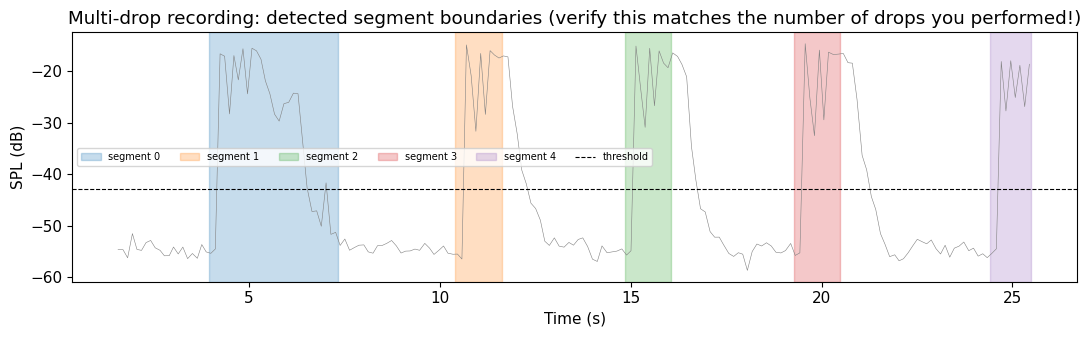

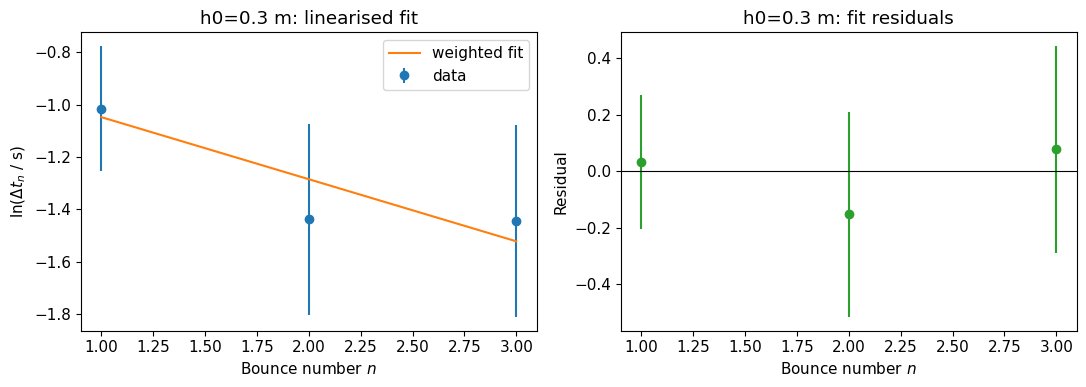

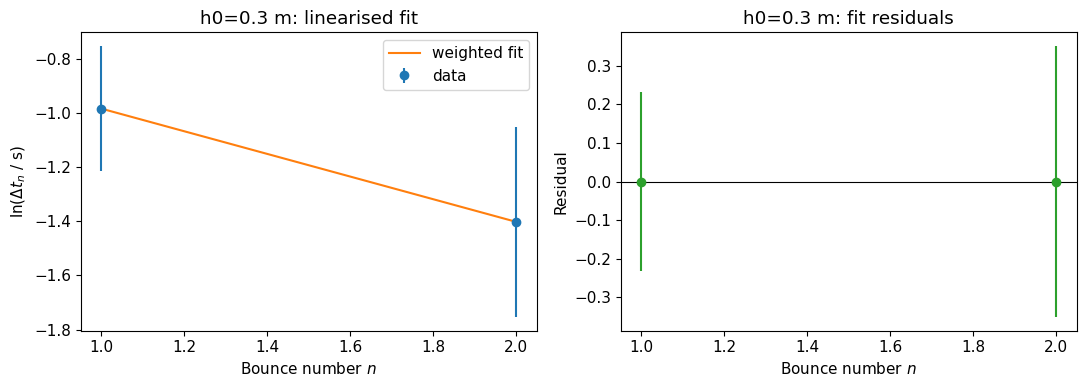

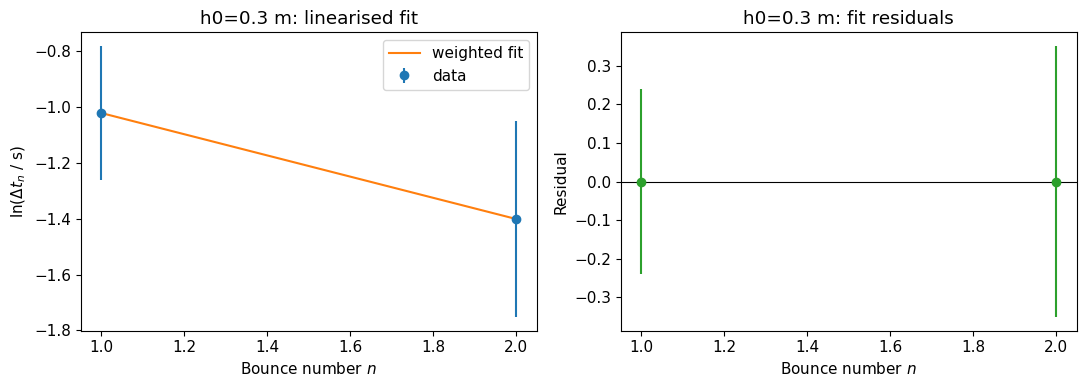

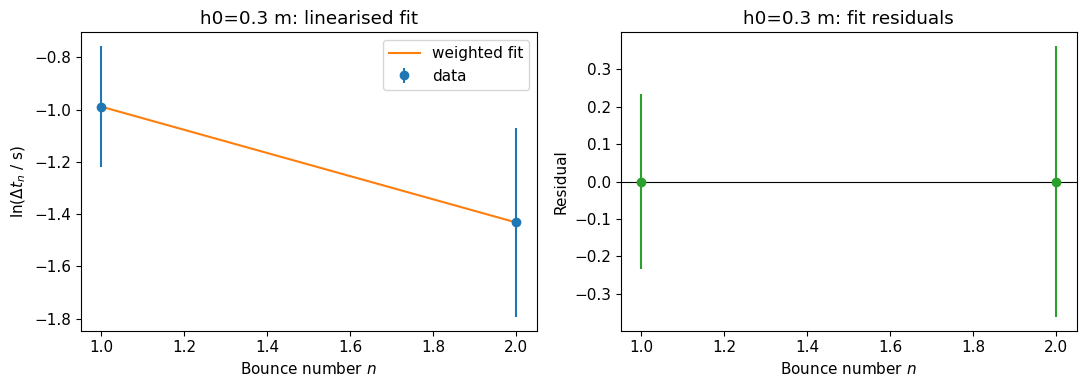

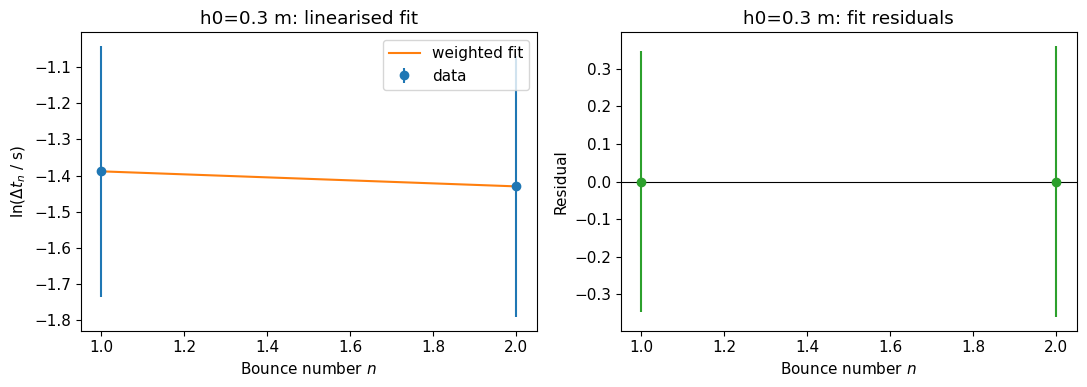

In [15]:
results_03m = process_multi_drop_recording(
    h03trial_raw, heights=[0.30] * 5, heights_err=[0.005] * 5,
    threshold_db=profile.recommended_threshold_db, min_gap_s=2.0,
    trim_start_s=1.5, trim_end_s=1.5, max_bounce_n=3, make_plots=True,
)


In [16]:
for i, r in enumerate(results_03m):
    chi2ndf = r["fit"].chi2_ndf
    chi2ndf_str = f"{chi2ndf:.2f}" if not np.isnan(chi2ndf) else "n/a (< 2 dof)"
    print(f"Repeat {i}: g = {r['g']:.2f} +/- {r['g_err']:.2f} m/s^2  "
          f"(n_used={r['n_used']}, chi2/ndf={chi2ndf_str})")

g_vals = np.array([r["g"] for r in results_03m])
g_errs = np.array([r["g_err"] for r in results_03m])
combo = fitting.pdg_combine(g_vals, g_errs)
g_ref = 9.783
pull = fitting.pull(combo.g_mean, combo.g_mean_err, g_ref)
print()
print(f"Combined (5 repeats, h0=0.30 m): g = {combo.g_mean:.2f} +/- {combo.g_mean_err:.2f} m/s^2")
print(f"chi2/ndf = {combo.chi2_ndf:.2f} (compatibility across repeats), "
      f"pull vs g_ref={g_ref} -> {pull:.2f} sigma")


Repeat 0: g = 12.17 +/- 9.77 m/s^2  (n_used=3, chi2/ndf=0.24)
Repeat 1: g = 7.46 +/- 8.67 m/s^2  (n_used=2, chi2/ndf=n/a (< 2 dof))
Repeat 2: g = 8.68 +/- 10.34 m/s^2  (n_used=2, chi2/ndf=n/a (< 2 dof))
Repeat 3: g = 7.16 +/- 8.44 m/s^2  (n_used=2, chi2/ndf=n/a (< 2 dof))
Repeat 4: g = 35.49 +/- 55.49 m/s^2  (n_used=2, chi2/ndf=n/a (< 2 dof))

Combined (5 repeats, h0=0.30 m): g = 8.84 +/- 4.59 m/s^2
chi2/ndf = 0.10 (compatibility across repeats), pull vs g_ref=9.783 -> -0.21 sigma


### Honest reading of this result

- This **is** a real measurement, not a placeholder -- known height, real
  multi-bounce audio, the same pipeline validated against synthetic ground
  truth in `notebooks/analysis.ipynb`.
- It is a **single-height repeatability check**, not the project's final
  result. `g = 8 h0 / A^2` is far more sensitive to the fitted intercept
  than to h0 itself, so one height alone cannot separate a genuine g
  offset from a shared systematic (e.g. a consistently mis-set threshold,
  or a consistent restitution assumption) that would shift every repeat
  the same way.
- Individual repeats mostly resolve only 2-3 impacts (n_used=2-3) --
  consistent with Section 1's aliasing prediction for a 0.3 m drop at
  Audio Amplitude's ~123 ms sampling. Two of the five repeats reduce to a
  2-point fit, which has zero degrees of freedom (no per-trial chi^2 is
  computable) -- the combined chi^2/ndf across all 5 repeats is the
  meaningful goodness-of-fit statistic here, not any single trial's.
- The pulls across repeats (printed above via each trial's g vs. the
  combined mean) are all small, which is a genuine, encouraging
  consistency check -- but consistency across repeats at one height is a
  *precision* check, not an *accuracy* check. The real test against
  $g_\mathrm{ref}$ still needs the full height series.

**Next step:** nine more heights (0.4-1.2 m) were recorded the same way,
meeting the protocol's >= 8-height target. That full multi-height analysis
has since moved out of this notebook and into `config.yaml` + `main.py`
(Section E below) -- the same underlying method as here, plus two
improvements this notebook does not have: reliability-weighted fitting
with a per-height (not blanket) resolvable-bounce cap, and a Physical
Consistency Filter that screens out individually corrupted intervals
(e.g. a missed bounce) before they reach the fit. Keeping one live
implementation avoids this notebook and `main.py` silently drifting apart.


## E. Full height series (0.3-1.2 m): see `main.py`

Run:
```
python main.py
```
This processes all ten heights with the current best methodology (§4.5a-4.8
of `report/process_overview.md`) and writes:

- `report/results_summary.csv` -- per-height and overall $g\pm\sigma$ and
  $\chi^2/\mathrm{ndf}$.
- `figures/g_vs_height.png` -- combined $g$ per height vs. $g_\mathrm{ref}$.
- `figures/dt_intervals_combined.png` and `figures/intervals/{h0}_dt_intervals.png`
  -- raw $\Delta t_1$/$\Delta t_2$/$\Delta t_3$ diagnostics, across heights
  and per height.
- `data/processed/interval_summary.csv` -- every trial's raw intervals.

**Current headline result (see `report/process_overview.md` §8-9 for the
full discussion, not reproduced here to avoid this notebook and that
document silently going out of sync):** overall cross-height compatibility
is currently poor and should not be quoted as a final answer, but the
cause is now diagnosed and split into two parts -- individually corrupted
intervals (a missed bounce inflating one $\Delta t_n$; mostly fixed by the
Physical Consistency Filter) and genuine trial-to-trial coefficient-of-
restitution variability at a couple of heights (real physics, not a bug).
